In [1]:
import pandas as pd
import sqlite3

## 1. Connection and reading

- так чисто изучаю таблицы

In [2]:
db = sqlite3.connect("../data/checking-logs.sqlite")

tables = db.execute("SELECT name FROM sqlite_master WHERE type='table';").fetchall()
tables


[('pageviews',),
 ('checker',),
 ('deadlines',),
 ('datamart',),
 ('test',),
 ('control',)]

In [3]:
pd.io.sql.read_sql("PRAGMA table_info(checker);", db)

,cid,name,type,notnull,dflt_value,pk
0,0,index,INTEGER,0,None,0
1,1,status,TEXT,0,None,0
2,2,success,INTEGER,0,None,0
3,3,timestamp,TIMESTAMP,0,None,0
4,4,numTrials,INTEGER,0,None,0
5,5,labname,TEXT,0,None,0
6,6,uid,TEXT,0,None,0


In [4]:
pd.io.sql.read_sql("PRAGMA table_info(pageviews);", db)

,cid,name,type,notnull,dflt_value,pk
0,0,index,INTEGER,0,None,0
1,1,uid,TEXT,0,None,0
2,2,datetime,TIMESTAMP,0,None,0


## 2. Запрос + подготовка фрейма

In [5]:
views = pd.read_sql("SELECT datetime FROM pageviews WHERE uid LIKE 'user_%'", db, parse_dates="datetime")
commits = pd.read_sql("SELECT timestamp FROM checker WHERE uid LIKE 'user_%'", db, parse_dates="timestamp")

views['views'] = views['datetime'].dt.date
commits['commits'] = commits['timestamp'].dt.date

g_views = views.groupby('views').size().rename('views')
g_commits = commits.groupby('commits').size().rename('commits')
df = pd.concat([g_views, g_commits], axis=1)
df.index.name = 'Date'
df.head()

,views,commits
Date,,
2020-04-17,1.0,23.0
2020-04-18,23.0,69.0
2020-04-19,15.0,33.0
2020-04-21,3.0,25.0
2020-04-22,1.0,28.0


## 3. Отрисовка

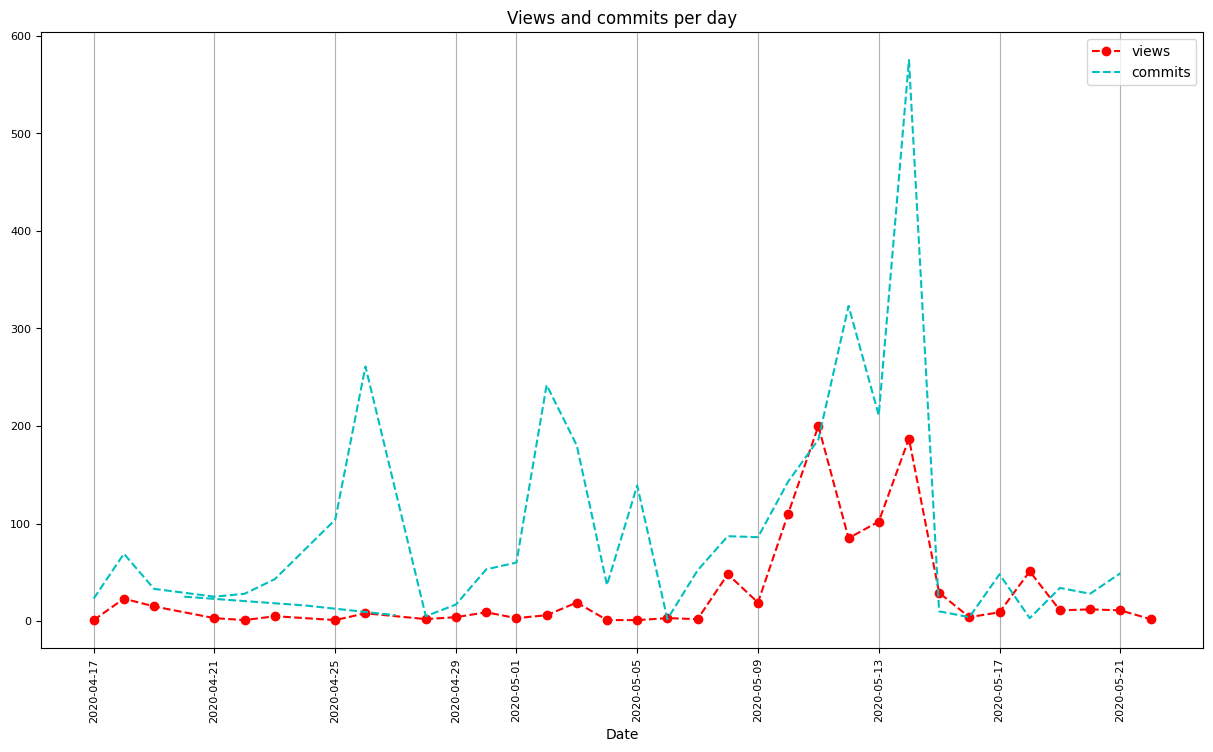

In [6]:
graph = df.plot(fontsize = 8, figsize = (15,8), title='Views and commits per day', rot = 90,
    style={
        'views': 'ro--',     
        'commits': 'c--'},
        grid = True,
        )
graph.yaxis.grid(False)

## 4. How many times was the number of views larger than 150? 
- The answer is 2

In [7]:
db.close()